In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [2]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [3]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Specifying the device and solver characteristics ##

In [ ]:
# Dimensions

gap = 200*nm
wvg_height = 220*nm
wvg1_width = 450*nm
wvg2_width = 940*nm
Ldc = 20*um
rad = 10*um

#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

# Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

# Solver dimensions and parameters
x_fdtd = 0
x_span_fdtd = Ldc + 2*rad + 2*um
y_fdtd = rad/2
y_span_fdtd = gap + wvg2_width + rad + 2*um
z_fdtd = 0
z_span_fdtd = 4*um

simulation_time = 5*(Ldc + np.pi*rad)/c

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 4

z_min_bc = 'Symmetric'

## Building the device ##

In [5]:
fdtdApi.addrect()
fdtdApi.set('name', 'wvg_1')
fdtdApi.set('x', 0)
fdtdApi.set('x span', Ldc)
fdtdApi.set('y min', gap/2)
fdtdApi.set('y max', gap/2 + wvg1_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'wvg_2')
fdtdApi.set('x', 0)
fdtdApi.set('x span', Ldc + 2*rad)
fdtdApi.set('y max', -gap/2)
fdtdApi.set('y min', -(gap/2 + wvg2_width))
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', '90_bend_1')
fdtdApi.set('radius', rad)
fdtdApi.set('base height', wvg_height)
fdtdApi.set('base width', wvg1_width)
fdtdApi.set('x', Ldc/2)
fdtdApi.set('y', rad+(gap+wvg1_width)/2)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('material', material)

fdtdApi.addobject('90_bend_wg')
fdtdApi.set('name', '90_bend_2')
fdtdApi.set('radius', rad)
fdtdApi.set('base height', wvg_height)
fdtdApi.set('base width', wvg1_width)
fdtdApi.set('x', -Ldc/2)
fdtdApi.set('y', rad+(gap+wvg1_width)/2)
fdtdApi.set('z', 0)
fdtdApi.set('first axis', 'x')
fdtdApi.set('second axis', 'y')
fdtdApi.set('rotation 1', 180)
fdtdApi.set('rotation 2', 180)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_1')
fdtdApi.set('x', -(rad + Ldc/2))
fdtdApi.set('x span', wvg1_width)
fdtdApi.set('y', rad + (gap+wvg1_width)/2 + 1*um)
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_2')
fdtdApi.set('x', (rad + Ldc/2))
fdtdApi.set('x span', wvg1_width)
fdtdApi.set('y', rad + (gap+wvg1_width)/2 + 1*um)
fdtdApi.set('y span', 2*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_3')
fdtdApi.set('x', -(Ldc/2 + rad + 1*um))
fdtdApi.set('x span', 2*um)
fdtdApi.set('y', -(gap+wvg2_width)/2)
fdtdApi.set('y span', wvg2_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

fdtdApi.addrect()
fdtdApi.set('name', 'rect_4')
fdtdApi.set('x', Ldc/2 + rad + 1*um)
fdtdApi.set('x span', 2*um)
fdtdApi.set('y', -(gap+wvg2_width)/2)
fdtdApi.set('y span', wvg2_width)
fdtdApi.set('z', 0)
fdtdApi.set('z span', wvg_height)
fdtdApi.set('material', material)

# add solver
fdtdApi.addfdtd()
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('simulation time', simulation_time)
fdtdApi.set('z min bc', z_min_bc)

# add ports 

fdtdApi.addport()
fdtdApi.set('name', 'port_1')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', -(rad+Ldc/2))
fdtdApi.set('x span', 3*um)
fdtdApi.set('y', rad + (gap+wvg1_width)/2 + 0.75*um)
fdtdApi.set('y span', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_2')
fdtdApi.set('injection axis', 'y-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', rad+Ldc/2)
fdtdApi.set('x span', 3*um)
fdtdApi.set('y', rad + (gap+wvg1_width)/2 + 0.75*um)
fdtdApi.set('y span', 0)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_3')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Forward')
fdtdApi.set('x', -(Ldc/2 + rad + 0.75*um))
fdtdApi.set('x span', 0)
fdtdApi.set('y', -(gap+wvg2_width)/2)
fdtdApi.set('y span', 3*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

fdtdApi.addport()
fdtdApi.set('name', 'port_4')
fdtdApi.set('injection axis', 'x-axis')
fdtdApi.set('direction', 'Backward')
fdtdApi.set('x', Ldc/2 + rad + 0.75*um)
fdtdApi.set('x span', 0)
fdtdApi.set('y', -(gap+wvg2_width)/2)
fdtdApi.set('y span', 3*um)
fdtdApi.set('z', 0)
fdtdApi.set('z span', 3*um)

# add monitors

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', z_fdtd)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', x_fdtd)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', y_fdtd)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('y max', rad + (gap+wvg1_width)/2 + 0.75*um)
fdtdApi.set('z', z_fdtd)

fdtdApi.save('Conversor_Directional_coupler_FDTD')

## Visualizing the electric field profile ##

In [6]:
fdtdApi.run()

### Visualizing the device ###

In [7]:
index_x = np.squeeze(fdtdApi.getdata('index', 'index_y').real)
x_device = np.squeeze(fdtdApi.getdata('index', 'x'))/um
y_device = np.squeeze(fdtdApi.getdata('index', 'y'))/um

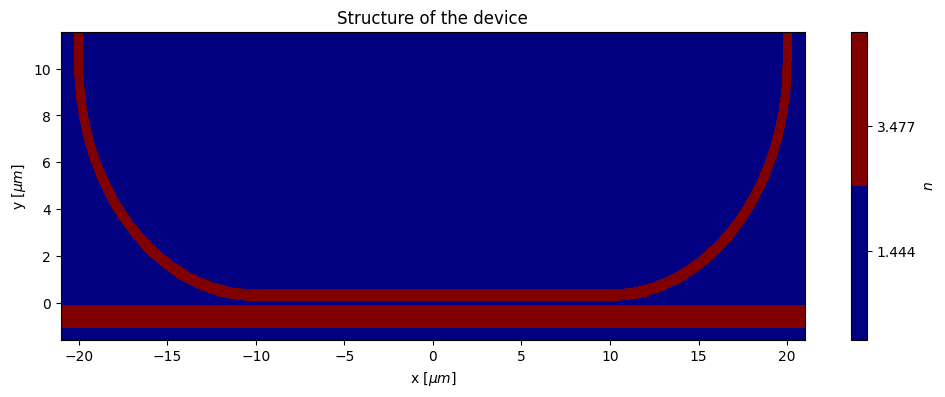

In [8]:
X, Y = np.meshgrid(x_device, y_device)
X, Y = np.transpose(X), np.transpose(Y)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

fig0 = plt.figure(figsize=(12,4))
im0 = plt.contourf(X, Y, index_x, 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im0, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Structure of the device')

plt.show()

In [9]:
eField = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

indxLambda = 24
x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

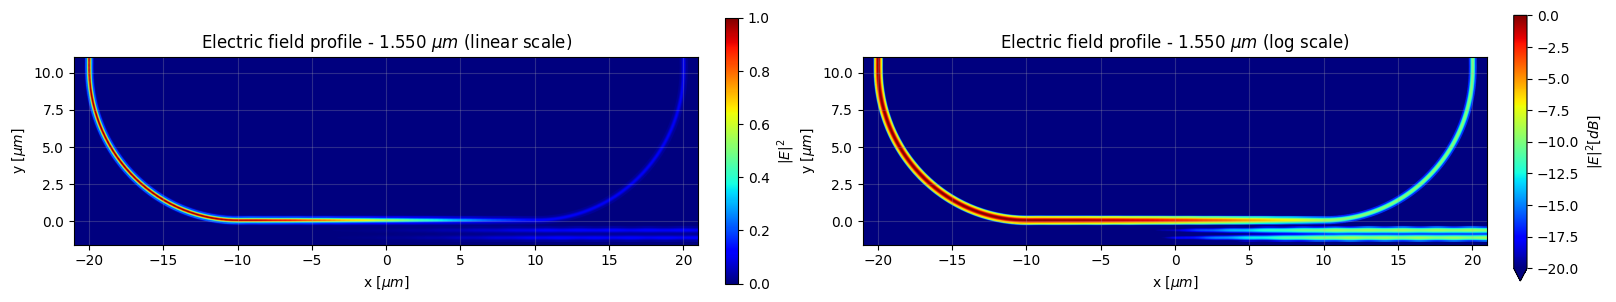

In [10]:
fig1, ax1 = plt.subplots(1,2,figsize=(16,4))
im1 = ax1[0].imshow(np.rot90(eField[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet')

colorbar = plt.colorbar(im1,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(10*np.log10(eField[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -20, vmax = 0, cmap = 'jet')

colorbar = plt.colorbar(im2, fraction = 0.02, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

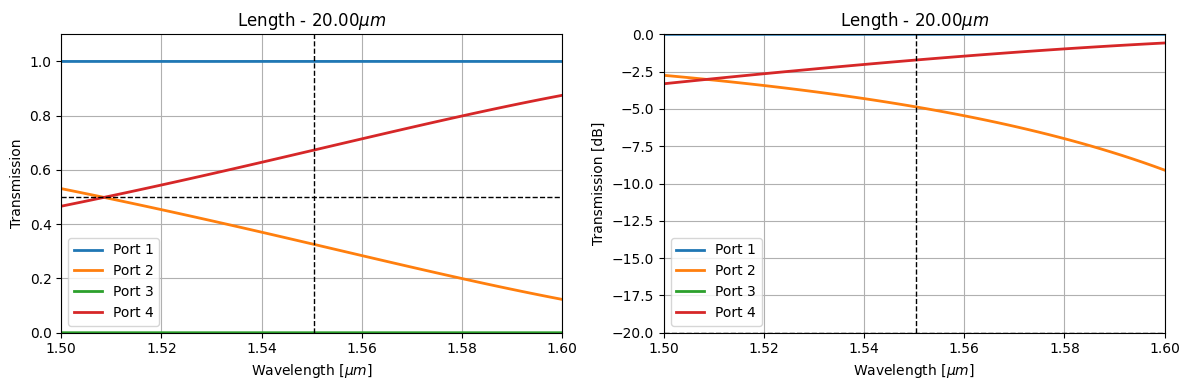

In [11]:
fig2, ax2 = plt.subplots(1,2,figsize=(12,4))
for i in range(1,5,1):
    ports = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    ax2[0].plot(ports['lambda']/um, np.abs(ports['T']), label = 'Port %d' %i, linewidth = 2)
    ax2[1].plot(ports['lambda']/um, 10*np.log10(np.abs(ports['T'])), label = 'Port %d' %i, linewidth = 2)

ax2[0].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[0].axhline(0.5, color = 'k', linestyle = '--', linewidth = 1)
ax2[0].set_xlabel(r'Wavelength [$\mu m$]')
ax2[0].set_ylabel(r'Transmission')
ax2[0].set_xlim([start_wavelength/um, stop_wavelength/um])
ax2[0].set_ylim([0,1.1])
ax2[0].set_title(r'Length - %.2f$\mu m$' % (Ldc/um))
ax2[0].grid(True)
ax2[0].legend(loc = 'best')

ax2[1].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax2[1].axhline(-20, color = 'k', linestyle = '--', linewidth = 1)
ax2[1].set_xlabel(r'Wavelength [$\mu m$]')
ax2[1].set_ylabel(r'Transmission [dB]')
ax2[1].set_xlim([start_wavelength/um, stop_wavelength/um])
ax2[1].set_ylim([-20,0])
ax2[1].set_title(r'Length - %.2f$\mu m$' % (Ldc/um))
ax2[1].grid(True)
ax2[1].legend(loc = 'best')

plt.tight_layout()
plt.show()

## Optimizing the device ##

In [162]:
fdtdApi.switchtolayout()

Ldc_start = 10*um
Ldc_stop = 30*um
Ldc_points = 21
Ldc_array = np.linspace(Ldc_start, Ldc_stop, Ldc_points)

In [ ]:
ports = np.zeros([Ldc_points,4, number_of_frequency_points])
fdtdApi.setnamed('movie', 'enabled', 0)
fdtdApi.setnamed('index', 'enabled', 0)

for i in range(0,len(Ldc_array),1):
    Ldc_wvg = Ldc_array[i]
    fdtdApi.switchtolayout()

    fdtdApi.setnamed('wvg_1', 'x span', Ldc_wvg)
    fdtdApi.setnamed('90_bend_1', 'x', Ldc_wvg/2)
    fdtdApi.setnamed('90_bend_2', 'x', -Ldc_wvg/2)
    fdtdApi.setnamed('wvg_2', 'x span', Ldc_wvg + 2*rad)
    fdtdApi.setnamed('rect_1', 'x', -(rad + Ldc_wvg/2))
    fdtdApi.setnamed('rect_2', 'x', (rad + Ldc_wvg/2))
    fdtdApi.setnamed('rect_3', 'x', -(Ldc_wvg/2 + rad + 1*um))
    fdtdApi.setnamed('rect_4', 'x', Ldc_wvg/2 + rad + 1*um)

    fdtdApi.setnamed('FDTD', 'x span', Ldc_wvg + 2*rad + 2*um)
    fdtdApi.setnamed('FDTD', 'simulation time', 5*(Ldc_wvg + np.pi*rad)/c)
    fdtdApi.setnamed('profile_xy', 'x span', Ldc_wvg + 2*rad + 2*um)

    fdtdApi.setnamed('FDTD::ports::port_1', 'x', -(rad + Ldc_wvg/2))
    fdtdApi.setnamed('FDTD::ports::port_2', 'x', rad + Ldc_wvg/2)
    fdtdApi.setnamed('FDTD::ports::port_3', 'x', -(Ldc_wvg/2 + rad + 0.5*um))
    fdtdApi.setnamed('FDTD::ports::port_4', 'x', Ldc_wvg/2 + rad + 0.5*um)

    fdtdApi.run()
    for j in range(1,5,1):
        ports[i,j-1,:] = fdtdApi.getresult('FDTD::ports::port_%d' %j, 'T')['T']

wvg1 = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']

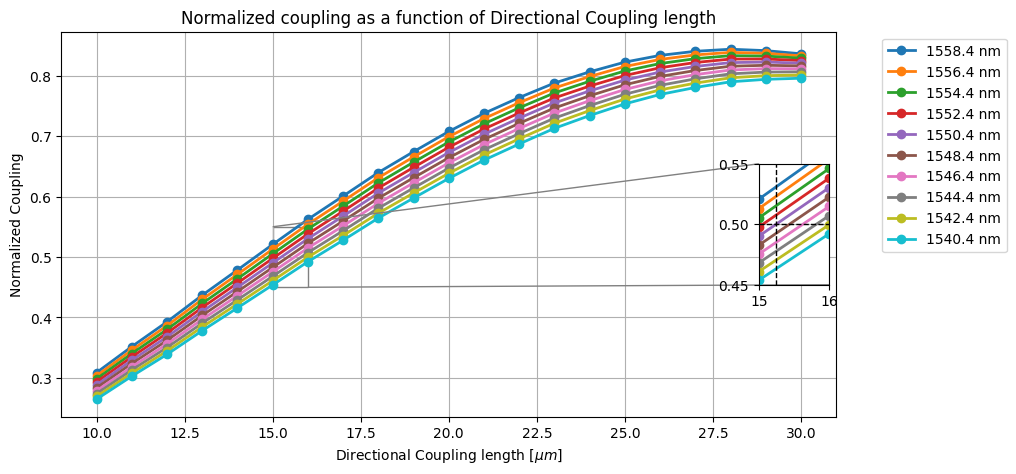

The DC length that presents a 50/50 coupling is 15.25 μm.


In [171]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig3, ax3 = plt.subplots(figsize=(10,5))
for i in range(20,30,1):
    ax3.plot(Ldc_array/um, np.abs(ports[:,3,i]), 'o-', label = "%5.1f nm" %(wvg1[i,0]/nm), linewidth = 2)

ax3.set_xlabel(r'Directional Coupling length [$\mu m$]')
ax3.set_ylabel('Normalized Coupling')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='best')
#ax3.set_xlim(Ldc_start/um, Ldc_stop/um)
ax3.grid(True)
ax3.set_title(r'Normalized coupling as a function of Directional Coupling length')
ax3.set

axins = zoomed_inset_axes(ax3, zoom = 2, loc = 'center right')
for i in range(20,30,1):
    axins.plot(Ldc_array/um, np.abs(ports[:,3,i]), '-o', label = "%5.1f nm" %(wvg1[i,0]/nm), linewidth = 2)

axins.set_xlim(15,16)
axins.set_ylim(0.45, 0.55)
axins.plot([15,16], [0.5, 0.5], 'k--', linewidth = 1)
x_local = 15.25
axins.plot([x_local, x_local], [0.45, 0.55], 'k--', linewidth = 1)

axins.grid(True)

mark_inset(ax3, axins, loc1=2, loc2=4, fc="none", ec="0.5", )
plt.draw()

plt.show()

Ldc_opt = 15.25 * um

print('\033[1mThe DC length that presents a 50/50 coupling is %.2f \u03BCm.\033[0m' %(Ldc_opt/um))

## Visualizing the electric field profile of the optimized DC ##

In [11]:
fdtdApi.switchtolayout()

Ldc_wvg = Ldc_opt

fdtdApi.setnamed('index', 'enabled', 1)

fdtdApi.setnamed('wvg_1', 'x span', Ldc_wvg)
fdtdApi.setnamed('90_bend_1', 'x', Ldc_wvg/2)
fdtdApi.setnamed('90_bend_2', 'x', -Ldc_wvg/2)
fdtdApi.setnamed('wvg_2', 'x span', Ldc_wvg + 2*rad)
fdtdApi.setnamed('rect_1', 'x', -(rad + Ldc_wvg/2))
fdtdApi.setnamed('rect_2', 'x', (rad + Ldc_wvg/2))
fdtdApi.setnamed('rect_3', 'x', -(Ldc_wvg/2 + rad + 1*um))
fdtdApi.setnamed('rect_4', 'x', Ldc_wvg/2 + rad + 1*um)

fdtdApi.setnamed('FDTD', 'x span', Ldc_wvg + 2*rad + 2*um)
fdtdApi.setnamed('FDTD', 'simulation time', 5*(Ldc_wvg + np.pi*rad)/c)
fdtdApi.setnamed('profile_xy', 'x span', Ldc_wvg + 2*rad + 2*um)
fdtdApi.setnamed('index', 'x span', Ldc_wvg + 2*rad + 2*um)

fdtdApi.setnamed('FDTD::ports::port_1', 'x', -(rad + Ldc_wvg/2))
fdtdApi.setnamed('FDTD::ports::port_2', 'x', rad + Ldc_wvg/2)
fdtdApi.setnamed('FDTD::ports::port_3', 'x', -(Ldc_wvg/2 + rad + 0.5*um))
fdtdApi.setnamed('FDTD::ports::port_4', 'x', Ldc_wvg/2 + rad + 0.5*um)

In [12]:
fdtdApi.run()

In [13]:
eField_2 = np.abs(np.squeeze(fdtdApi.getelectric('profile_xy')))**2

x_efield2 = fdtdApi.getdata('profile_xy', 'x')
y_efield2 = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin2 = np.min(x_efield2) / um
xmax2 = np.max(x_efield2) / um
ymin2 = np.min(y_efield2) / um
ymax2 = np.max(y_efield2) / um

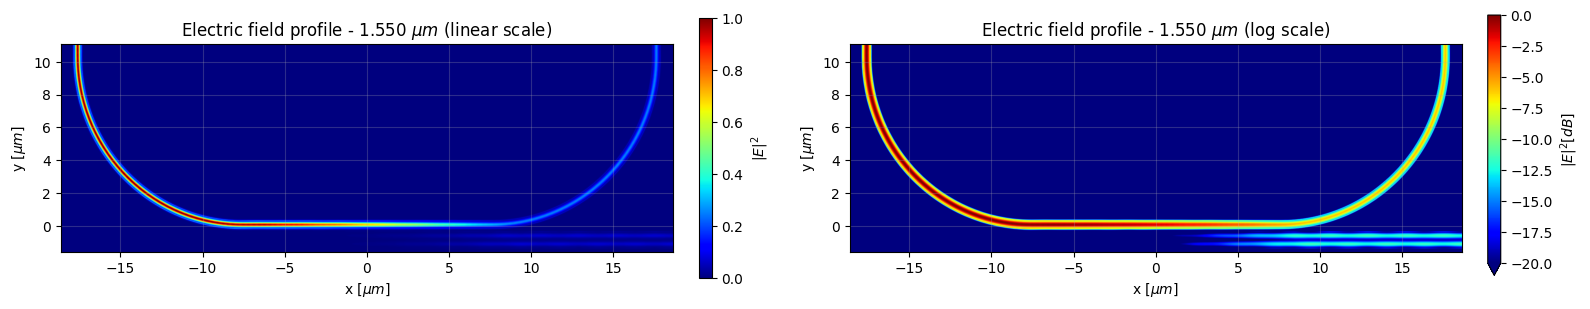

In [14]:
fig4, ax4 = plt.subplots(1,2,figsize=(16,4))
im3 = ax4[0].imshow(np.rot90(eField_2[:,:,indxLambda]), extent=[xmin2, xmax2, ymin2, ymax2], vmin = 0, vmax = 1, cmap = 'jet')

colorbar = plt.colorbar(im3,fraction = 0.02, pad =0.04, label = r'$|E|^2$')

ax4[0].set_xlabel(r'x [$\mu m$]')
ax4[0].set_ylabel(r'y [$\mu m$]')
ax4[0].set_title(r'Electric field profile - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax4[0].grid(which='major', alpha = 0.25)

im4 = ax4[1].imshow(np.rot90(10*np.log10(eField_2[:,:,indxLambda])), extent = [xmin2, xmax2, ymin2, ymax2], vmin = -20, vmax = 0, cmap = 'jet')

colorbar = plt.colorbar(im4, fraction = 0.02, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax4[1].set_xlabel(r'x [$\mu m$]')
ax4[1].set_ylabel(r'y [$\mu m$]')
ax4[1].set_title(r'Electric field profile - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax4[1].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

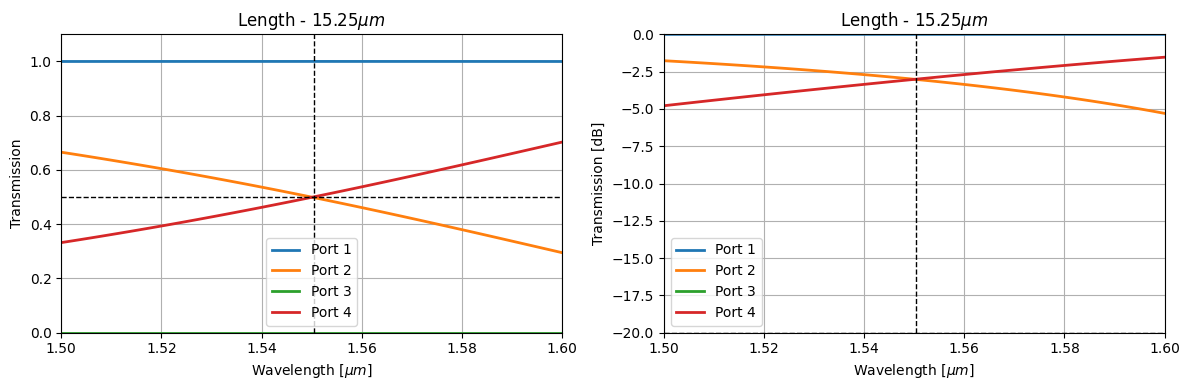

In [15]:
fig5, ax5 = plt.subplots(1,2,figsize=(12,4))
for i in range(1,5,1):
    ports_opt = fdtdApi.getresult('FDTD::ports::port_%d' %i, 'T')
    ax5[0].plot(ports_opt['lambda']/um, np.abs(ports_opt['T']), label = 'Port %d' %i, linewidth = 2)
    ax5[1].plot(ports_opt['lambda']/um, 10*np.log10(np.abs(ports_opt['T'])), label = 'Port %d' %i, linewidth = 2)

ax5[0].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax5[0].axhline(0.5, color = 'k', linestyle = '--', linewidth = 1)
ax5[0].set_xlabel(r'Wavelength [$\mu m$]')
ax5[0].set_ylabel(r'Transmission')
ax5[0].set_xlim([start_wavelength/um, stop_wavelength/um])
ax5[0].set_ylim([0,1.1])
ax5[0].set_title(r'Length - %.2f$\mu m$' % (Ldc_opt/um))
ax5[0].grid(True)
ax5[0].legend(loc = 'best')

ax5[1].axvline(central_wavelength[indxLambda,0]/um, color = 'k', linestyle = '--', linewidth = 1)
ax5[1].axhline(-20, color = 'k', linestyle = '--', linewidth = 1)
ax5[1].set_xlabel(r'Wavelength [$\mu m$]')
ax5[1].set_ylabel(r'Transmission [dB]')
ax5[1].set_xlim([start_wavelength/um, stop_wavelength/um])
ax5[1].set_ylim([-20,0])
ax5[1].set_title(r'Length - %.2f$\mu m$' % (Ldc_opt/um))
ax5[1].grid(True)
ax5[1].legend(loc = 'best')

plt.tight_layout()
plt.show()

In [32]:
fdtdApi.close()